<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Capstone_project/blob/main/ML_Movie_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Capstone Project Setup Movie Prediction (Problem + Dataset + Goals)

# New section

In [ ]:
# Step 1: Import drive data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
# Step 2: Insert path and read the file
movies = '/content/drive/MyDrive/Colab Notebooks/Dataset/TMDB_movie_dataset_v11.csv'

In [ ]:
# Step 4: Show first 5 rows
df = pd.read_csv(movies)
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [ ]:
# Step 3: Basic Info
print('Dataset Shape:', df.shape)
print('\nDataset Columns:',df.columns.tolist())

Dataset Shape: (1279347, 24)

Dataset Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


In [ ]:
# Step 5: Check Missing Values
print('\nMissing Values in Dataset:')
print(df.isnull().sum())


Missing Values in Dataset:
id                            0
title                        15
vote_average                  0
vote_count                    0
status                        0
release_date             249772
revenue                       0
runtime                       0
adult                         0
backdrop_path            950605
budget                        0
homepage                1145964
imdb_id                  642805
original_language             0
original_title               15
overview                 280153
popularity                    0
poster_path              430557
tagline                 1100521
genres                   540603
production_companies     718919
production_countries     596647
spoken_languages         572990
keywords                 949686
dtype: int64


In [ ]:
# --- Create Classification Target (Hit / Flop) ---
df["hit_flop"] = df.apply(lambda row: "Hit" if row["revenue"] > row["budget"] else "Flop", axis=1)

In [ ]:
df.tail()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,hit_flop
1279342,802778,Ink,0.0,0,Released,2021-06-14,0,2,False,/eb5QjysMry90FWjnlJFoNuRmgPm.jpg,...,Being a neat freak is easy when you’ve got eig...,0.6000,/34CKAE9HQEG8bp0tr2PaOpBvf0p.jpg,NaN,Animation,NaN,NaN,NaN,NaN,Flop
1279343,802779,The Haunting of Pluckley Village,0.0,0,Planned,NaN,0,0,False,NaN,...,The story focuses on the most haunted village ...,0.6000,NaN,Based on the true story of Britain's most haun...,Horror,"Rellik Films, Greenway Entertainment",United Kingdom,English,"village, haunted house",Flop
1279344,802780,Precious Blood,0.0,0,Released,1982-03-09,0,60,False,NaN,...,A one act play where a woman and a man share ...,0.7720,/ls0gjmz0INtJqRJXXoUYk5VEQkv.jpg,NaN,"Drama, TV Movie",NaN,NaN,English,NaN,Flop
1279345,802782,a film by m+m,0.0,0,Released,NaN,0,2,False,/aSXmvwHptrLG7fEFsC14ob6ahj6.jpg,...,Two wacky wizard friends bump and cruise throu...,0.6000,NaN,NaN,Animation,NaN,NaN,NaN,NaN,Flop
1279346,1537554,Stake Out,0.0,0,Post Production,NaN,0,0,False,NaN,...,A former couple who stake out the man they sus...,0.0143,NaN,NaN,"Horror, Mystery","Good and Done, Princess Pictures",Australia,English,NaN,Flop


In [ ]:
# Check distribution of new column
print(df["hit_flop"].value_counts())

hit_flop
Flop    1263233
Hit       16114
Name: count, dtype: int64


In [ ]:
# Preview
print(df[["title", "budget", "revenue", "hit_flop"]].head())

             title     budget     revenue hit_flop
0        Inception  160000000   825532764      Hit
1     Interstellar  165000000   701729206      Hit
2  The Dark Knight  185000000  1004558444      Hit
3           Avatar  237000000  2923706026      Hit
4     The Avengers  220000000  1518815515      Hit


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279347 entries, 0 to 1279346
Data columns (total 25 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1279347 non-null  int64  
 1   title                 1279332 non-null  object 
 2   vote_average          1279347 non-null  float64
 3   vote_count            1279347 non-null  int64  
 4   status                1279347 non-null  object 
 5   release_date          1029575 non-null  object 
 6   revenue               1279347 non-null  int64  
 7   runtime               1279347 non-null  int64  
 8   adult                 1279347 non-null  bool   
 9   backdrop_path         328742 non-null   object 
 10  budget                1279347 non-null  int64  
 11  homepage              133383 non-null   object 
 12  imdb_id               636542 non-null   object 
 13  original_language     1279347 non-null  object 
 14  original_title        1279332 non-

In [ ]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.279347e+06,1.279347e+06,1.279347e+06,1.279347e+06,1.279347e+06,1.279347e+06,1.279347e+06
mean,8.213988e+05,1.698970e+00,1.676908e+01,6.521378e+05,4.572135e+01,2.522816e+05,1.120143e+00
std,4.374592e+05,2.936138e+00,3.002794e+02,1.872950e+07,6.121538e+01,5.167650e+06,7.159948e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.534885e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,8.322870e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01,0.000000e+00,6.000000e-01
75%,1.210536e+06,3.800000e+00,1.000000e+00,0.000000e+00,8.700000e+01,0.000000e+00,8.400000e-01
max,1.537776e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [ ]:
# Check missing values
# movies.isnull().sum().sort_values(ascending=False)

# Show only columns with missing values
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)

print(missing_cols)


homepage                1145964
tagline                 1100521
backdrop_path            950605
keywords                 949686
production_companies     718919
imdb_id                  642805
production_countries     596647
spoken_languages         572990
genres                   540603
poster_path              430557
overview                 280153
release_date             249772
original_title               15
title                        15
dtype: int64


In [ ]:
print("Before dropping missing titles:", df.shape)

# Drop rows where 'title' is missing
df = df.dropna(subset=['title'])

print("After dropping missing titles:", df.shape)

Before dropping missing titles: (1279347, 25)
After dropping missing titles: (1279332, 25)


# To create a Regression Model

In [ ]:
# Select important columns for regression
regression_cols = [
    'budget', 'runtime', 'popularity',
    'vote_average', 'vote_count',
    'genres', 'production_companies',
    'release_date', 'original_language',
    'revenue'   # target column
]

df_reg = df[regression_cols].copy()

print("Shape of regression dataframe:", df_reg.shape)
df_reg.head()


Shape of regression dataframe: (1279332, 10)


,budget,runtime,popularity,vote_average,vote_count,genres,production_companies,release_date,original_language,revenue
0,160000000,148,83.952,8.364,34495,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,en,825532764
1,165000000,169,140.241,8.417,32571,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...",2014-11-05,en,701729206
2,185000000,152,130.643,8.512,30619,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...",2008-07-16,en,1004558444
3,237000000,162,79.932,7.573,29815,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...",2009-12-15,en,2923706026
4,220000000,143,98.082,7.710,29166,"Science Fiction, Action, Adventure",Marvel Studios,2012-04-25,en,1518815515


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Missing values
df_reg.isnull().sum()

# Check invalid entries
print("Invalid revenue:", (df_reg['revenue'] <= 0).sum())
print("Invalid budget:", (df_reg['budget'] <= 0).sum())
print("Invalid runtime:", (df_reg['runtime'] <= 0).sum())

# Expectation: Many rows with budget=0 or revenue=0 → not usable for regression.

Invalid revenue: 1256773
Invalid budget: 1209170
Invalid runtime: 376352


In [ ]:
# Keep only rows with valid values rest to clean data
df_reg_clean = df_reg[
    (df_reg['revenue'] > 0) &
    (df_reg['budget'] > 0) &
    (df_reg['runtime'] > 0)
].copy()

print("Original shape:", df_reg.shape)
print("After cleaning:", df_reg_clean.shape)


Original shape: (1279332, 10)
After cleaning: (13682, 10)


In [ ]:
df_reg_clean.describe()

,budget,runtime,popularity,vote_average,vote_count,revenue
count,1.368200e+04,13682.000000,13682.000000,13682.000000,13682.000000,1.368200e+04
mean,1.834727e+07,93.919383,14.302736,5.111348,1117.775398,5.427272e+07
std,3.695925e+07,58.018989,53.352762,2.980427,2635.244817,1.598168e+08
min,1.000000e+00,1.000000,0.000000,0.000000,0.000000,1.000000e+00
25%,1.000000e+04,83.000000,0.709250,4.370000,1.000000,1.542975e+04
50%,4.000000e+06,99.000000,8.673000,6.162000,122.000000,4.237560e+06
75%,2.000000e+07,117.000000,17.157750,6.978000,967.000000,3.680000e+07
max,8.000000e+08,999.000000,2994.357000,10.000000,34495.000000,5.000000e+09


### Revenue Distribution

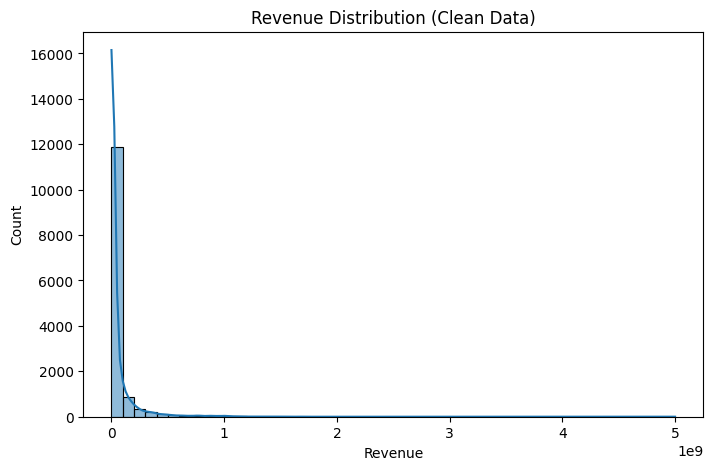

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_reg_clean['revenue'], bins=50, kde=True)
plt.title("Revenue Distribution (Clean Data)")
plt.xlabel("Revenue")
plt.show()


# 👉 Extremely right-skewed (few blockbusters make billions)

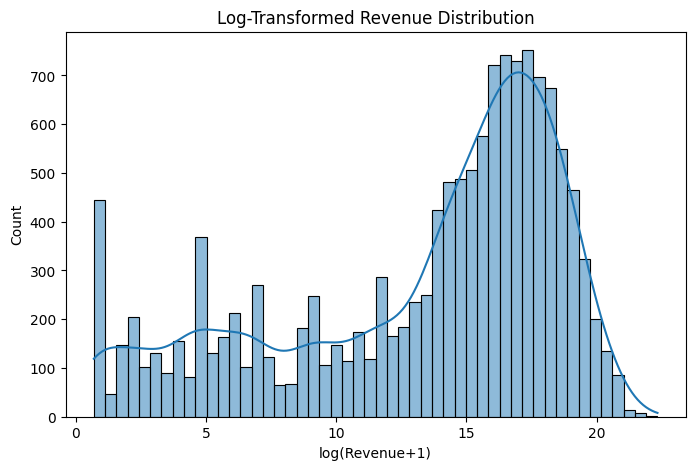

In [ ]:
# You can also look at log-transformed revenue:

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_reg_clean['revenue']), bins=50, kde=True)
plt.title("Log-Transformed Revenue Distribution")
plt.xlabel("log(Revenue+1)")
plt.show()

# 👉 Much more normal-looking, better for regression.

### Budget Distribution

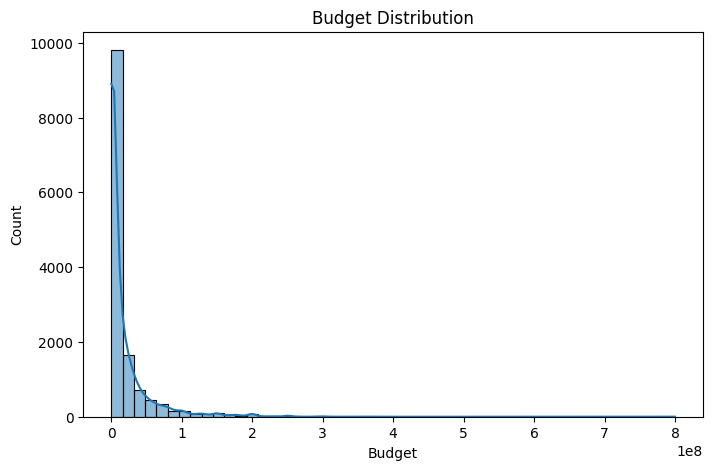

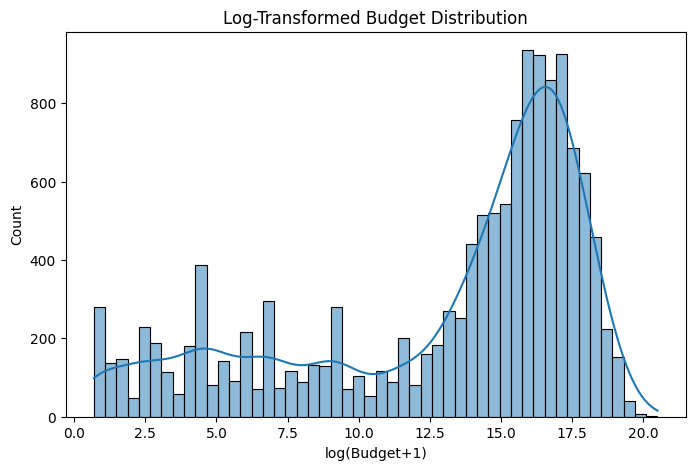

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_reg_clean['budget'], bins=50, kde=True)
plt.title("Budget Distribution")
plt.xlabel("Budget")
plt.show()

# Log transform
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_reg_clean['budget']), bins=50, kde=True)
plt.title("Log-Transformed Budget Distribution")
plt.xlabel("log(Budget+1)")
plt.show()

# 👉 highly skewed, log-transform is useful.


### Runtime Distribution

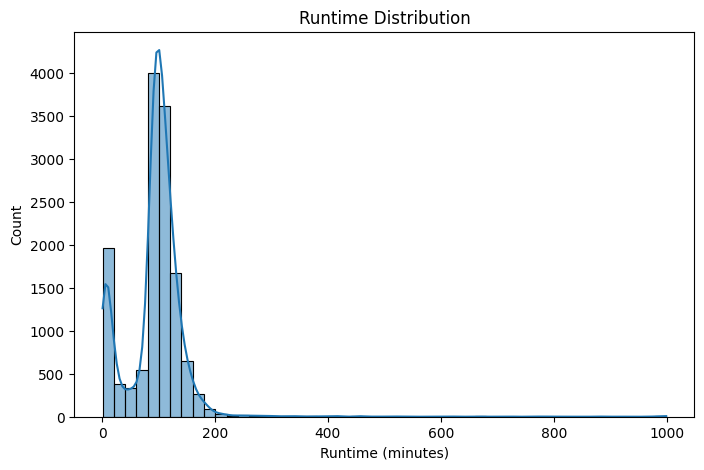

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_reg_clean['runtime'], bins=50, kde=True)
plt.title("Runtime Distribution")
plt.xlabel("Runtime (minutes)")
plt.show()

### Popularity Distribution

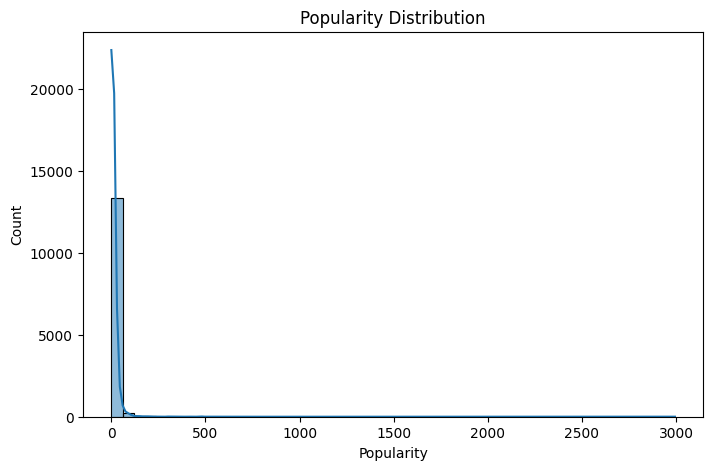

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_reg_clean['popularity'], bins=50, kde=True)
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.show()


### Correlation Heatmap

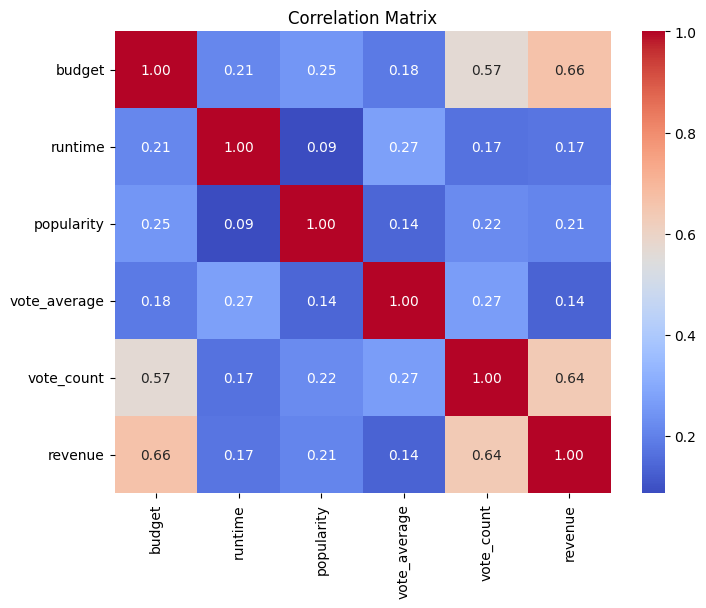

In [ ]:
num_cols = ['budget','runtime','popularity','vote_average','vote_count','revenue']
corr = df_reg_clean[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


### Revenue vs Budget (Scatter Plot)

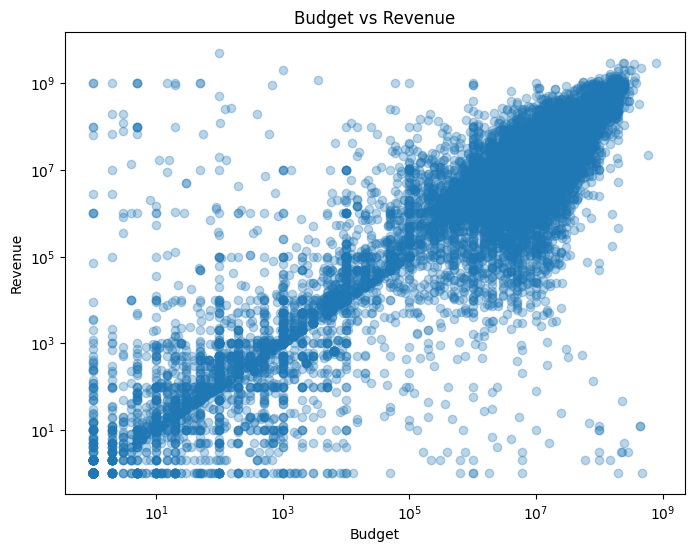

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_reg_clean['budget'], df_reg_clean['revenue'], alpha=0.3)
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue")
plt.xscale("log")
plt.yscale("log")
plt.show()


###  Revenue vs Popularity

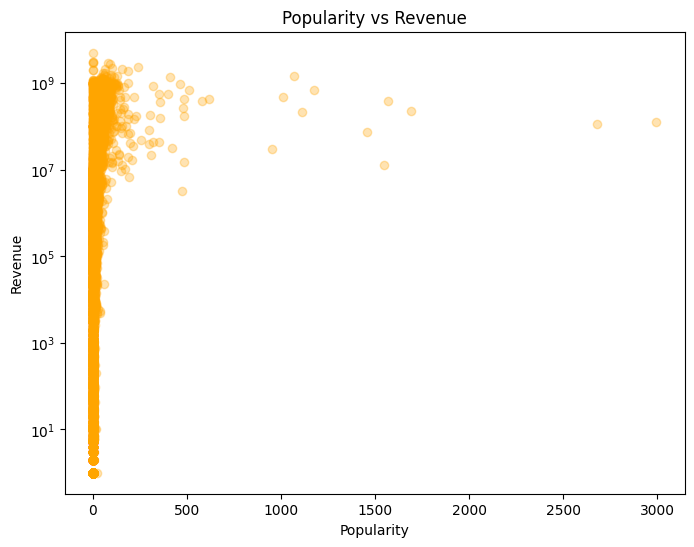

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_reg_clean['popularity'], df_reg_clean['revenue'], alpha=0.3, color="orange")
plt.xlabel("Popularity")
plt.ylabel("Revenue")
plt.title("Popularity vs Revenue")
plt.yscale("log")
# plt.xscale("log")
plt.show()


### Genre-Level Average Revenue

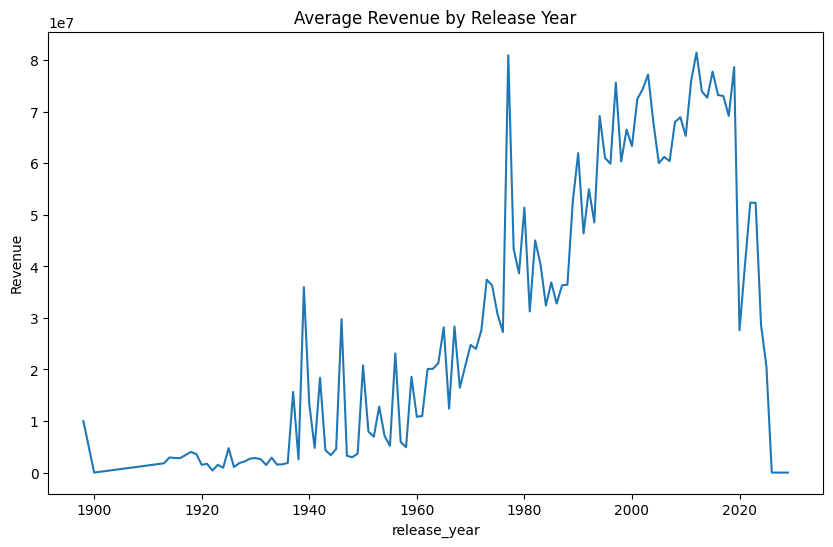

In [ ]:
df_reg_clean['release_year'] = pd.to_datetime(df_reg_clean['release_date'], errors='coerce').dt.year

year_revenue = df_reg_clean.groupby('release_year')['revenue'].mean()

plt.figure(figsize=(10,6))
year_revenue.plot()
plt.title("Average Revenue by Release Year")
plt.ylabel("Revenue")
plt.show()


### Release Year Trend

In [ ]:
df_reg_clean.head()

,budget,runtime,popularity,vote_average,vote_count,genres,production_companies,release_date,original_language,revenue,release_year
0,160000000,148,83.952,8.364,34495,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,en,825532764,2010.0
1,165000000,169,140.241,8.417,32571,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...",2014-11-05,en,701729206,2014.0
2,185000000,152,130.643,8.512,30619,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...",2008-07-16,en,1004558444,2008.0
3,237000000,162,79.932,7.573,29815,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...",2009-12-15,en,2923706026,2009.0
4,220000000,143,98.082,7.710,29166,"Science Fiction, Action, Adventure",Marvel Studios,2012-04-25,en,1518815515,2012.0


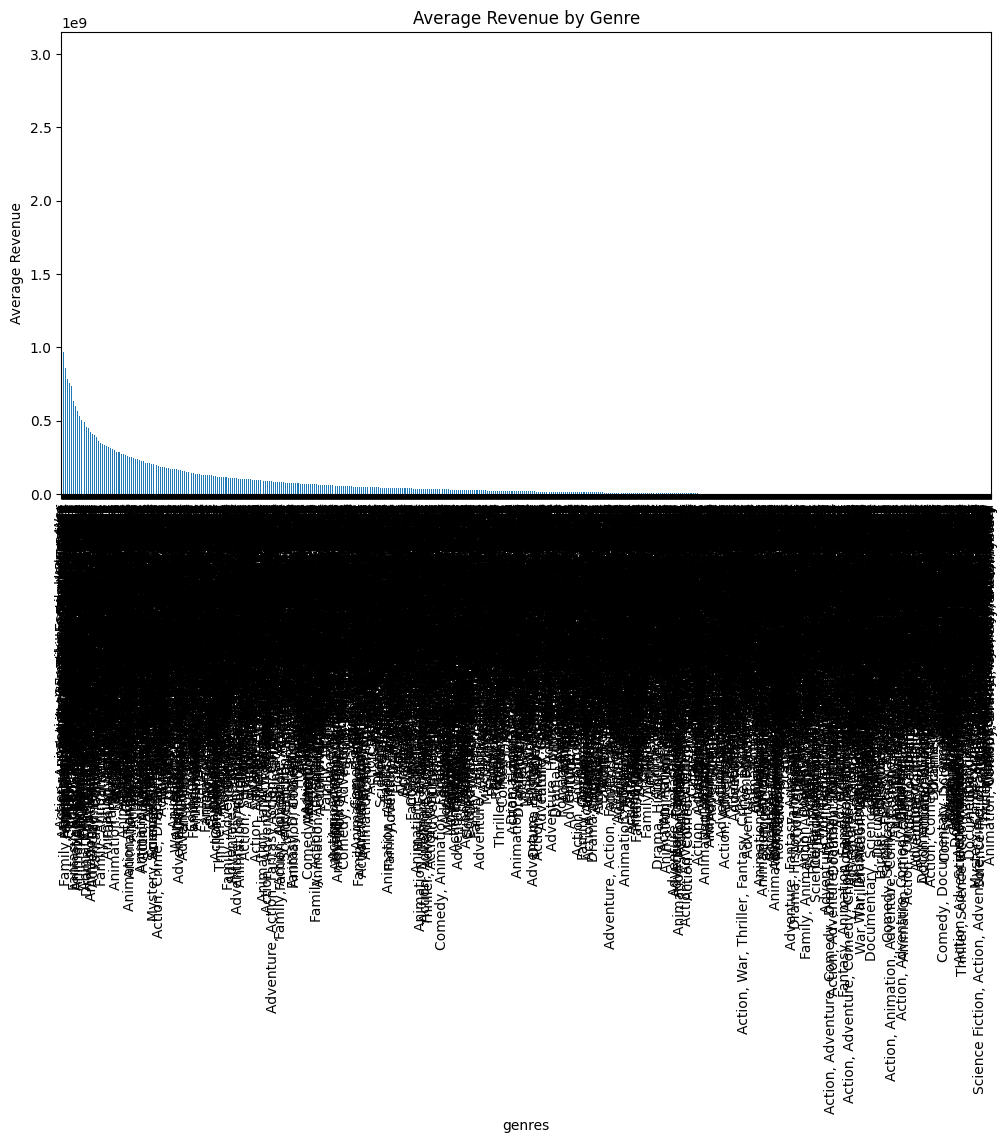

In [ ]:
genre_revenue = df_reg_clean.explode('genres').groupby('genres')['revenue'].mean().sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
genre_revenue.plot(kind='bar')
plt.title("Average Revenue by Genre")
plt.ylabel("Average Revenue")
plt.show()

After exploding, shape: (30963, 11)
      budget  runtime  popularity  vote_average  vote_count            genres  \
0  160000000      148      83.952         8.364       34495            Action   
0  160000000      148      83.952         8.364       34495   Science Fiction   
0  160000000      148      83.952         8.364       34495         Adventure   
1  165000000      169     140.241         8.417       32571         Adventure   
1  165000000      169     140.241         8.417       32571             Drama   

                                production_companies release_date  \
0  Legendary Pictures, Syncopy, Warner Bros. Pict...   2010-07-15   
0  Legendary Pictures, Syncopy, Warner Bros. Pict...   2010-07-15   
0  Legendary Pictures, Syncopy, Warner Bros. Pict...   2010-07-15   
1  Legendary Pictures, Syncopy, Lynda Obst Produc...   2014-11-05   
1  Legendary Pictures, Syncopy, Lynda Obst Produc...   2014-11-05   

  original_language    revenue  release_year  
0              

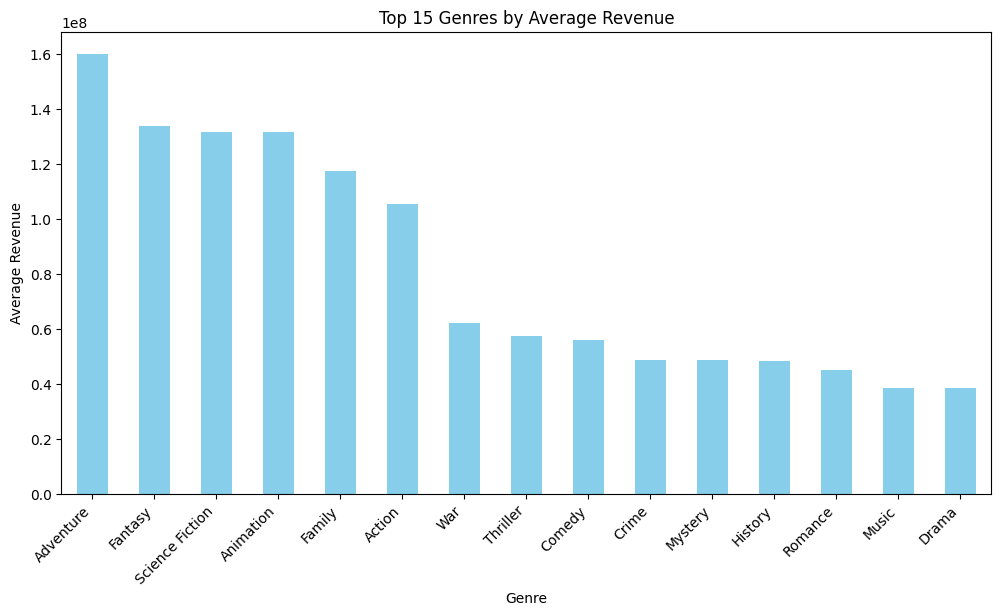

In [ ]:
# Step 1: Make sure genres are split into lists
df_reg_clean['genres'] = df_reg_clean['genres'].str.split(',')

# Step 2: Explode into separate rows
df_exploded = df_reg_clean.explode('genres')
print("After exploding, shape:", df_exploded.shape)
print(df_exploded.head())

# Step 3: Remove whitespace (important!)
df_exploded['genres'] = df_exploded['genres'].str.strip()

# Step 4: Group by single genre
genre_revenue = df_exploded.groupby('genres')['revenue'].mean().sort_values(ascending=False)
print(genre_revenue.head(15))

# Step 5: Plot top 15 genres
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
genre_revenue.head(15).plot(kind='bar', color='skyblue')
plt.title("Top 15 Genres by Average Revenue")
plt.ylabel("Average Revenue")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha='right')
plt.show()

# Feature Engineering

In [ ]:
df = df_exploded.copy()

In [ ]:
df.head()

,budget,runtime,popularity,vote_average,vote_count,genres,production_companies,release_date,original_language,revenue,release_year
0,160000000,148,83.952,8.364,34495,Action,"Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,en,825532764,2010.0
0,160000000,148,83.952,8.364,34495,Science Fiction,"Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,en,825532764,2010.0
0,160000000,148,83.952,8.364,34495,Adventure,"Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,en,825532764,2010.0
1,165000000,169,140.241,8.417,32571,Adventure,"Legendary Pictures, Syncopy, Lynda Obst Produc...",2014-11-05,en,701729206,2014.0
1,165000000,169,140.241,8.417,32571,Drama,"Legendary Pictures, Syncopy, Lynda Obst Produc...",2014-11-05,en,701729206,2014.0


# Target Transformation

### 1. Handle Skewness in target (revenue)

In [ ]:
# Revenue is highly skewed (some movies earn billions, most earn little).
# Log transformation reduces skew and helps regression learn better.
df['log_revenue'] = np.log1p(df['revenue'])   # log1p = log(1+x), safe for 0

### 2. Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
# Scale features like budget, runtime, popularity, etc. to bring them
# to the same range (important for algorithms sensitive to magnitude).
numeric_features = ['budget', 'runtime', 'popularity', 'vote_average', 'vote_count']
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### 3. Date Features (release_date → month, quarter)

In [ ]:
# Month/Quarter effect: movies released in holidays (Nov/Dec/July) often earn more.
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')   # error - NaT
df['release_month'] = df['release_date'].dt.month.fillna(0).astype(int)
df['release_quarter'] = df['release_date'].dt.quarter.fillna(0).astype(int)

date_features = ['release_month', 'release_quarter']
date_transformer = StandardScaler()

### 4. Genres (Multi-label → Multi-hot encoding)

In [ ]:
# One movie can have multiple genres → convert to binary columns.
# Example: Action=1, Comedy=0, Drama=1 means Action+Drama movie.
df['genres'] = df['genres'].apply(lambda x: x if isinstance(x, list) else [x])
df_exploded = df.explode('genres')
df_exploded = pd.get_dummies(df_exploded, columns=['genres'], prefix="genre")
df = df_exploded.groupby(df_exploded.index).max()


### 5. Production Companies --> top 20

In [ ]:
df.head()

,budget,runtime,popularity,vote_average,vote_count,production_companies,release_date,original_language,revenue,release_year,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,160000000,148,83.952,8.364,34495,"Legendary Pictures, Syncopy, Warner Bros. Pict...",2010-07-15,en,825532764,2010.0,...,False,False,False,False,False,True,False,False,False,False
1,165000000,169,140.241,8.417,32571,"Legendary Pictures, Syncopy, Lynda Obst Produc...",2014-11-05,en,701729206,2014.0,...,False,False,False,False,False,True,False,False,False,False
2,185000000,152,130.643,8.512,30619,"DC Comics, Legendary Pictures, Syncopy, Isobel...",2008-07-16,en,1004558444,2008.0,...,False,False,False,False,False,False,False,True,False,False
3,237000000,162,79.932,7.573,29815,"Dune Entertainment, Lightstorm Entertainment, ...",2009-12-15,en,2923706026,2009.0,...,False,False,False,False,False,True,False,False,False,False
4,220000000,143,98.082,7.710,29166,Marvel Studios,2012-04-25,en,1518815515,2012.0,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Step 1: Replace missing values with '' and split string into a list of companies
df['production_companies'] = df['production_companies'].fillna('').apply(lambda x: x.split(','))

# Step 2: Clean the company names → remove extra spaces, ignore empty strings
df['production_companies'] = df['production_companies'].apply(lambda x: [c.strip() for c in x if c.strip() != ''])

# Step 3: Explode → create separate rows for each company (1 movie → multiple rows if many companies)
df_exploded = df.explode('production_companies')

# Step 4: Identify the top 20 most frequent companies in the dataset
top_companies = df_exploded['production_companies'].value_counts().nlargest(20).index
print("Top 20 Companies:", top_companies.tolist())

# Step 5: Keep only top 20 companies → others grouped into "Other"
df_exploded['production_companies'] = df_exploded['production_companies'].apply(
    lambda x: x if x in top_companies else 'Other'
)

# Step 6: One-hot encode companies (multi-hot representation if a movie has multiple companies)
df_exploded = pd.get_dummies(df_exploded, columns=['production_companies'], prefix="company")

# Step 7: Group rows back to one row per movie, taking max() so that if a movie worked with multiple companies,
#         all those companies will have 1 in their respective columns
df = df_exploded.groupby(df_exploded.index).max()


Top 20 Companies: ['Warner Bros. Pictures', 'Universal Pictures', 'Paramount', '20th Century Fox', 'Columbia Pictures', 'Metro-Goldwyn-Mayer', 'New Line Cinema', 'Walt Disney Pictures', 'Canal+', 'Touchstone Pictures', 'Miramax', 'Lionsgate', 'United Artists', 'StudioCanal', 'Summit Entertainment', 'Relativity Media', 'DreamWorks Pictures', 'TriStar Pictures', 'Focus Features', 'Village Roadshow Pictures']


### 6. Original Language → top 10

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Step 1: Find the top 10 most frequent original languages in the dataset
top_langs = df['original_language'].value_counts().nlargest(10).index
print("Top 10 Languages:", top_langs.tolist())

# Step 2: Replace any language not in the top 10 with "Other"
df['original_language'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'Other'
)

# Step 3: Define categorical features and transformer
# OneHotEncoder will convert language column into binary columns
# handle_unknown="ignore" ensures that if a new language appears in test data,
# it won't cause an error (it will just be ignored)
categorical_features = ['original_language']
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

Top 10 Languages: ['en', 'hi', 'fr', 'es', 'ru', 'ja', 'ta', 'fa', 'zh', 'it']


### 7. ColumnTransformer Setup

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("date", date_transformer, date_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder='passthrough'   # keep genre/company dummy columns
)

### 8. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=['revenue', 'log_revenue'])
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 9. Apply preprocessing

In [ ]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Train shape:", X_train_prepared.shape)
print("Test shape:", X_test_prepared.shape)

Train shape: (10945, 60)
Test shape: (2737, 60)


# Model Building & Evaluation


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

In [ ]:
# 1. Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

In [ ]:
# 2. Train & Evaluate
results = []

In [ ]:
type(X_train_prepared)

numpy.ndarray

In [ ]:
print(pd.DataFrame(X_train_prepared).dtypes.head(20))

0             object
1             object
2             object
3             object
4             object
5             object
6             object
7             object
8             object
9             object
10            object
11            object
12            object
13            object
14            object
15            object
16            object
17            object
18    datetime64[ns]
19            object
dtype: object


In [ ]:
from sklearn.impute import SimpleImputer

# -------------------------------------------------------------------
# STEP 1: Handle Datetime Columns
# -------------------------------------------------------------------
for df in [X_train, X_test]:
    datetime_cols = df.select_dtypes(include=['datetime', 'datetime64', 'datetime64[ns]']).columns
    for col in datetime_cols:
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek
        df.drop(columns=[col], inplace=True)

# -------------------------------------------------------------------
# STEP 2: Preprocess Data & Impute Missing Values (NaN)
# -------------------------------------------------------------------
# Pass through your preprocessor
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# Fill missing (NaN) values using SimpleImputer
imputer = SimpleImputer(strategy='median')  # or strategy='mean'
X_train_prepared = imputer.fit_transform(X_train_prepared)
X_test_prepared = imputer.transform(X_test_prepared)

# -------------------------------------------------------------------
# STEP 3: Model Training & Evaluation Loop
# -------------------------------------------------------------------
results = []

for name, model in models.items():
    # Fit on training data
    model.fit(X_train_prepared, y_train)

    # Predict
    y_pred = model.predict(X_test_prepared)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

# View evaluation summary
results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'R2'])
print(results_df)

               Model      RMSE       MAE        R2
0  Linear Regression  3.515475  2.580734  0.594361
1   Ridge Regression  3.515474  2.580373  0.594361
2   Lasso Regression  3.516173  2.579238  0.594200
3      Random Forest  2.085717  1.270231  0.857215
4            XGBoost  2.066014  1.255552  0.859900


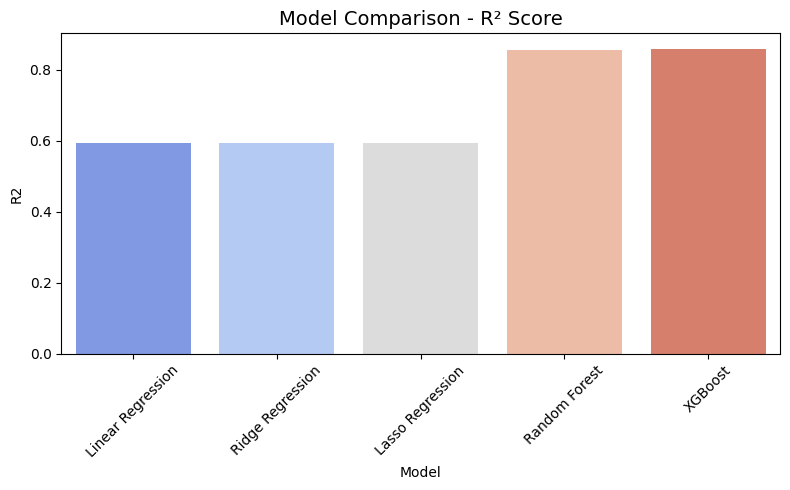

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Plot R² Score Comparison ----
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2",             # Changed from "R2 Score" to match results_df column name
    hue="Model",        # Added to prevent Seaborn palette warnings
    palette="coolwarm",
    legend=False
)

plt.title("Model Comparison - R² Score", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3337/547617446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")


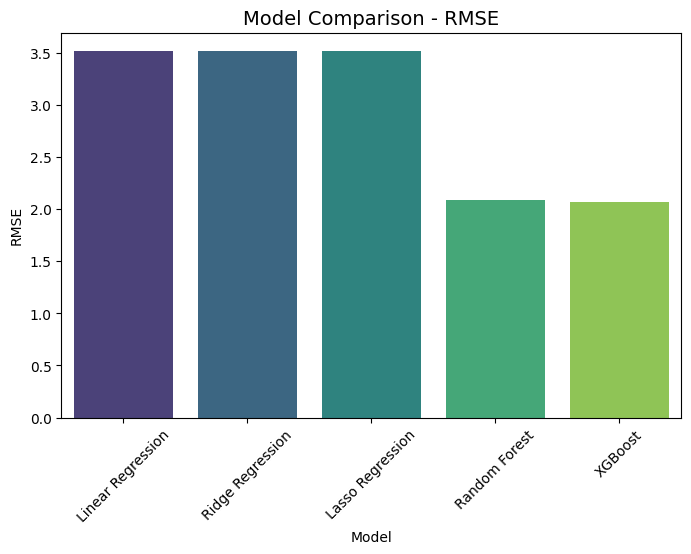

In [ ]:
# ---- Plot RMSE Comparison ----
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")
plt.title("Model Comparison - RMSE", fontsize=14)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3337/562145506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", palette="magma")


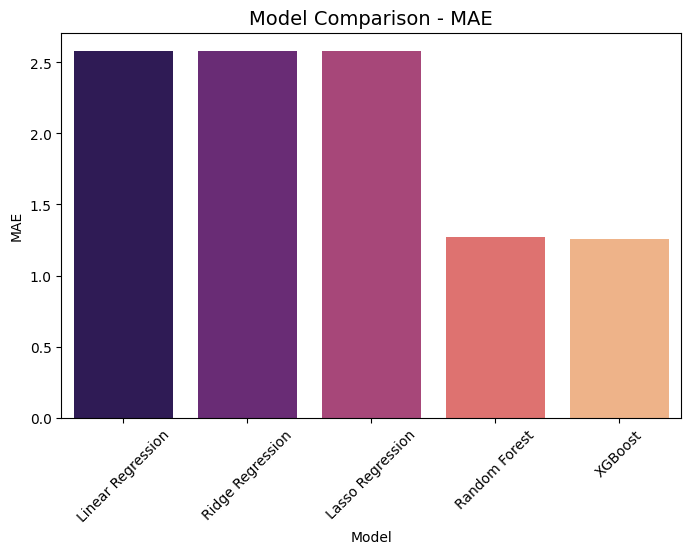

In [ ]:
# ---- Plot MAE Comparison ----
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="MAE", palette="magma")
plt.title("Model Comparison - MAE", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Feature Importance

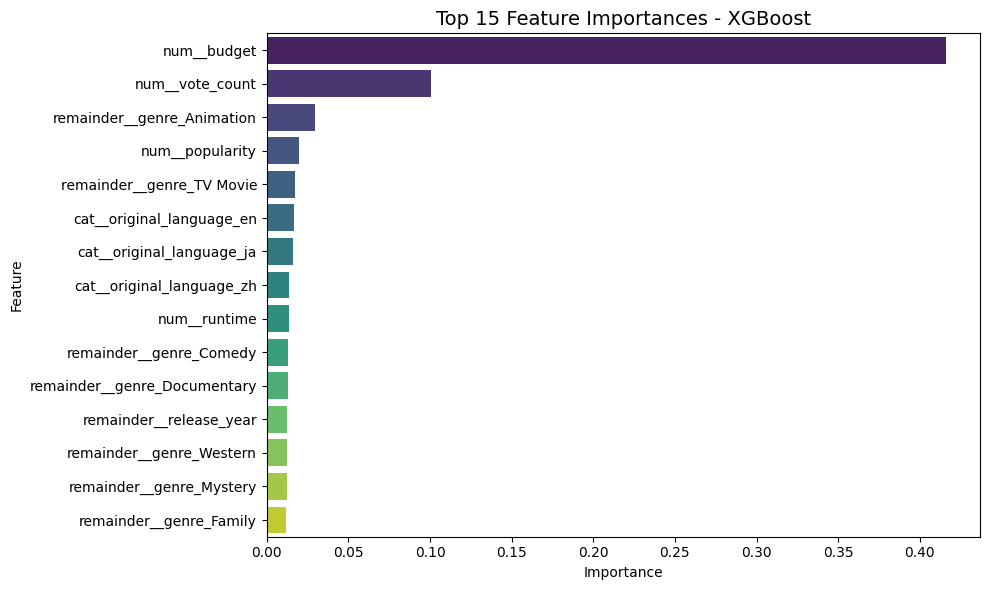

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---- Get feature names after preprocessing ----
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback to feature indices if get_feature_names_out is unavailable
    feature_names = [f"Feature_{i}" for i in range(X_train_prepared.shape[1])]

# ---- XGBoost Feature Importance ----
xgb_model = models["XGBoost"]
xgb_importances = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_importance_df.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",       # Added to prevent Seaborn palette warnings
    palette="viridis",
    legend=False
)

plt.title("Top 15 Feature Importances - XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3337/1681484783.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance_df.head(15), x="Importance", y="Feature", palette="magma")


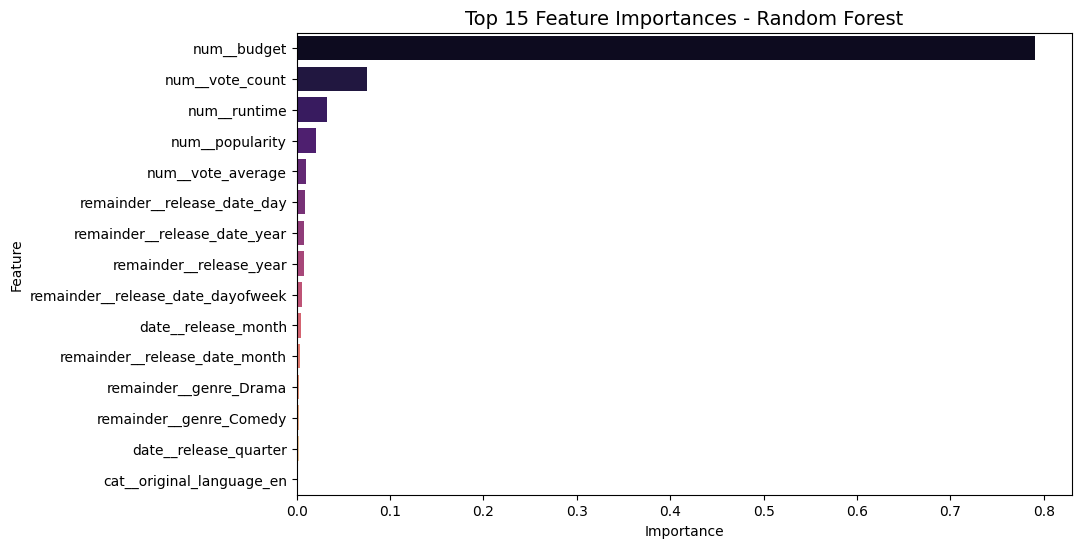

In [ ]:
# ---- Random Forest Feature Importance ----
rf_model = models["Random Forest"]
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df.head(15), x="Importance", y="Feature", palette="magma")
plt.title("Top 15 Feature Importances - Random Forest", fontsize=14)
plt.show()

# hyperparameter tuning using RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Base model
xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

# Parameter grid for RandomizedSearch
param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 2, 5]
}

In [ ]:
# Randomized Search (faster than GridSearch)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                  # number of random combinations to try
    scoring='r2',               # optimize for R²
    cv=3,                       # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Fit on training data
random_search.fit(X_train_prepared, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 300, 500, 800],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [1, 2, 5],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best CV R² Score:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV R² Score: 0.8518522259670475


In [ ]:
# Retrain with best params on full training data
best_xgb = random_search.best_estimator_

In [ ]:
# Evaluate on test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = best_xgb.predict(X_test_prepared)

In [ ]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Test RMSE: 2.0361829812501373
Test MAE: 1.253209357531648
Test R²: 0.8639164185289151


Model Comparison Results:
               Model      RMSE       MAE  R2 Score
4            XGBoost  2.072533  1.253049  0.859014
3      Random Forest  2.088384  1.269624  0.856849
1   Ridge Regression  3.525779  2.609931  0.591979
0  Linear Regression  3.525784  2.610331  0.591978
2   Lasso Regression  3.526722  2.608483  0.591761

In [ ]:
def square(n):
    for i in range(3):
        yield i**2


In [ ]:
square(2)

<generator object square at 0x7e9249556b50>

In [ ]:
for i in square(4):
    print(i)

0
1
4


## Feature Importance with Tuned Model

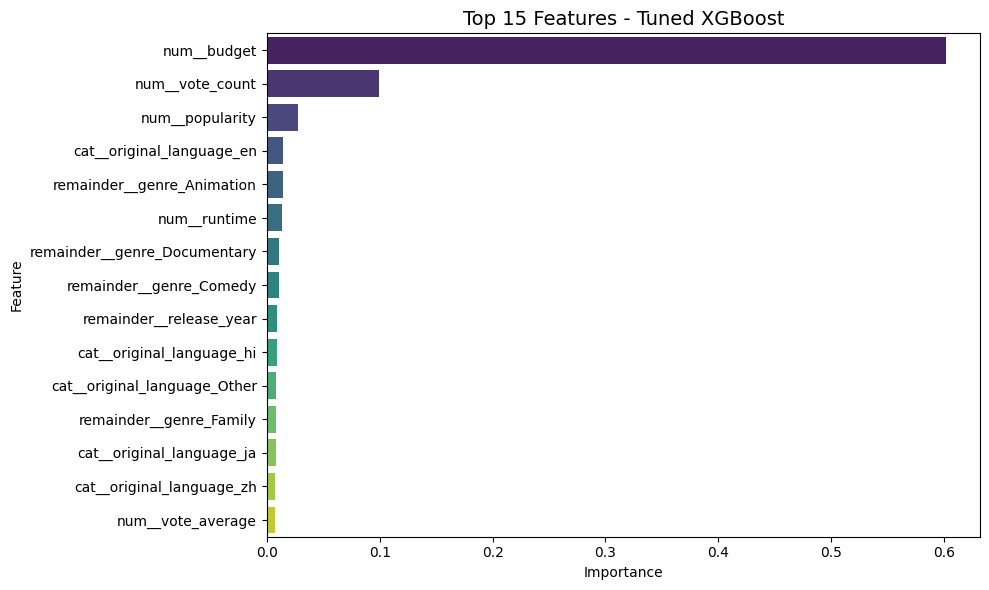

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---- Get feature names and importances from your tuned model ----
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback if get_feature_names_out is unavailable
    feature_names = [f"Feature_{i}" for i in range(len(best_xgb.feature_importances_))]

tuned_importances = best_xgb.feature_importances_

tuned_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tuned_importances
}).sort_values("Importance", ascending=False)

# ---- Plot Feature Importance ----
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tuned_importance_df.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",       # Prevents Seaborn palette/hue warnings
    palette="viridis",
    legend=False
)

plt.title("Top 15 Features - Tuned XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

##  Residual Analysis (Check Model Quality)

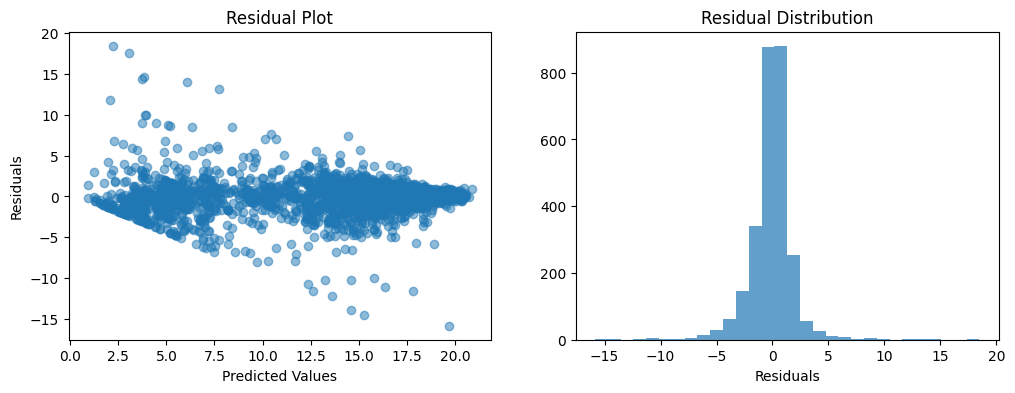

In [ ]:
# Check if predictions are biased
residuals = y_test - y_pred

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7)
plt.xlabel("Residuals")
plt.title("Residual Distribution")
plt.show()

## Predicting new value

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# STEP 1: Copy 1 row from X_train to match exact columns and dtypes
# -------------------------------------------------------------------
new_movie_df = X_train.iloc[[0]].copy()

# Reset numeric columns to 0 without breaking categorical string dtypes
for col in new_movie_df.columns:
    if pd.api.types.is_numeric_dtype(new_movie_df[col]):
        new_movie_df[col] = 0

# -------------------------------------------------------------------
# STEP 2: Fill in numerical and date feature values
# -------------------------------------------------------------------
movie_features = {
    'budget': 200000000,
    'runtime': 120,
    'popularity': 85.0,
    'vote_average': 7.5,
    'vote_count': 5000,
    'release_date_year': 2024,
    'release_date_month': 7,
    'release_date_day': 15,
    'release_date_dayofweek': 0,
    'release_year': 2024,
    'release_month': 7,
    'release_quarter': 3,
    'original_language': 'en'
}

for col, val in movie_features.items():
    if col in new_movie_df.columns:
        new_movie_df[col] = val

# -------------------------------------------------------------------
# STEP 3: Set active one-hot encoded categories to 1
# -------------------------------------------------------------------
active_categories = [
    'genre_Action',
    'genre_Adventure',
    'company_Marvel Studios'
]

for cat in active_categories:
    if cat in new_movie_df.columns:
        new_movie_df[cat] = 1

# -------------------------------------------------------------------
# STEP 4: Transform and Predict
# -------------------------------------------------------------------
new_movie_prepared = preprocessor.transform(new_movie_df)

if 'imputer' in globals():
    new_movie_prepared = imputer.transform(new_movie_prepared)

predicted_revenue = best_xgb.predict(new_movie_prepared)
predicted_revenue_actual = np.expm1(predicted_revenue)

print(f"Predicted Revenue: ${predicted_revenue_actual[0]:,.0f}")

Predicted Revenue: $648,441,856


In [ ]:
def predict_movie_revenue(movie_data, preprocessor, model):
    """
    Predict revenue for a new movie using the trained model

    Parameters:
    movie_data: dict with movie features
    preprocessor: fitted preprocessor_new
    model: trained best_xgb model
    """
    # Get all expected columns
    expected_columns = preprocessor.get_feature_names_out()

    # Create complete DataFrame with zeros
    movie_df = pd.DataFrame(0, index=[0], columns=expected_columns)

    # Fill numeric features
    numeric_mappings = {
        'budget': 'num__budget',
        'runtime': 'num__runtime',
        'popularity': 'num__popularity',
        'vote_average': 'num__vote_average',
        'vote_count': 'num__vote_count'
    }

    for feature, col_name in numeric_mappings.items():
        if feature in movie_data:
            movie_df[col_name] = movie_data[feature]

    # Fill date features
    date_mappings = {
        'release_month': 'date__release_month',
        'release_quarter': 'date__release_quarter',
        'release_year': 'date__release_year'
    }

    for feature, col_name in date_mappings.items():
        if feature in movie_data:
            movie_df[col_name] = movie_data[feature]

    # Fill categorical features
    if 'original_language' in movie_data:
        lang_col = f"cat__original_language_{movie_data['original_language']}"
        if lang_col in movie_df.columns:
            movie_df[lang_col] = 1

    """What happens:

        User provides: 'original_language': 'en'
        Function creates column name: 'cat__original_language_en'
        Sets that column to 1, all others remain 0"""

    # Fill genres
    if 'genres' in movie_data:
        for genre in movie_data['genres']:
            genre_col = f"cat__genre_{genre}"
            if genre_col in movie_df.columns:
                movie_df[genre_col] = 1

    """What happens:

        User provides: 'genres': ['Action', 'Adventure']
        Function sets both genre columns to 1"""

    # Fill production companies
    if 'production_companies' in movie_data:
        for company in movie_data['production_companies']:
            company_col = f"cat__company_{company}"
            if company_col in movie_df.columns:
                movie_df[company_col] = 1

    # Predict
    predicted_log = model.predict(movie_df)
    predicted_revenue = np.expm1(predicted_log)

    """Model predicts in log scale (what it was trained on)
        np.expm1() converts back to actual dollars
        Returns the revenue amount"""

    return predicted_revenue[0]

In [ ]:


# -------------------------------------------------------------------
# STEP 1: Define prediction helper function
# -------------------------------------------------------------------
def predict_movie_revenue(data_dict, preprocessor_obj, model_obj):
    # Copy 1 row from X_train to match exact feature names and dtypes
    df_input = X_train.iloc[[0]].copy()

    # Reset numeric feature columns to 0
    for col in df_input.columns:
        if pd.api.types.is_numeric_dtype(df_input[col]):
            df_input[col] = 0

    # Fill scalar values from dictionary (e.g., budget, runtime, release_year)
    for key, value in data_dict.items():
        if key in df_input.columns:
            df_input[key] = value

    # Map list fields (genres, companies) to one-hot encoded columns
    if 'genres' in data_dict and isinstance(data_dict['genres'], list):
        for g in data_dict['genres']:
            if f"genre_{g}" in df_input.columns:
                df_input[f"genre_{g}"] = 1

    if 'production_companies' in data_dict and isinstance(data_dict['production_companies'], list):
        for c in data_dict['production_companies']:
            if f"company_{c}" in df_input.columns:
                df_input[f"company_{c}"] = 1

    # Apply preprocessing transformations
    prepared_data = preprocessor_obj.transform(df_input)

    if 'imputer' in globals():
        prepared_data = imputer.transform(prepared_data)

    # Predict log-revenue and invert back to dollars using expm1
    log_pred = model_obj.predict(prepared_data)
    return np.expm1(log_pred)[0]

# -------------------------------------------------------------------
# STEP 2: Input movie data
# -------------------------------------------------------------------
new_movie_data = {
    'budget': 200000000,
    'runtime': 120,
    'popularity': 85.0,
    'vote_average': 7.5,
    'vote_count': 5000,
    'release_month': 7,
    'release_quarter': 3,
    'release_year': 2024,
    'original_language': 'en',
    'genres': ['Action', 'Adventure'],
    'production_companies': ['Marvel Studios']
}

# -------------------------------------------------------------------
# STEP 3: Execute prediction using 'preprocessor'
# -------------------------------------------------------------------
predicted_revenue = predict_movie_revenue(new_movie_data, preprocessor, best_xgb)
print(f"Predicted Revenue: ${predicted_revenue:,.0f}")

Predicted Revenue: $765,879,424


# (Movie Analysis in CLASSIFICATION)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = df

In [ ]:
data.head()

,budget,runtime,popularity,vote_average,vote_count,original_language,release_year,release_month,release_quarter,genre_Action,...,company_TriStar Pictures,company_United Artists,company_Universal Pictures,company_Village Roadshow Pictures,company_Walt Disney Pictures,company_Warner Bros. Pictures,release_date_year,release_date_month,release_date_day,release_date_dayofweek
5253,2033000,102,17.934,7.447,665,en,1938.0,5,2,False,...,False,False,False,False,False,True,1938.0,5.0,13.0,4.0
1050633,120000,11,0.600,0.000,0,en,NaN,0,0,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
455,75000000,108,45.871,7.114,7458,en,2016.0,11,4,False,...,False,False,True,False,False,False,2016.0,11.0,23.0,2.0
8104,15000000,122,10.934,5.996,351,en,1993.0,4,2,False,...,False,False,False,False,False,False,1993.0,4.0,23.0,4.0
31221,342000,99,4.992,6.702,42,en,1935.0,8,3,False,...,False,False,False,False,False,False,1935.0,8.0,23.0,4.0


### -----------------------------
### 1. Remove duplicates
### -----------------------------

In [ ]:
# copy dataset
df = data.copy()   #preserve the original data


df = df.drop_duplicates()

# Removes all duplicate rows from the dataframe and updates the dataframe with the cleaned version.

### -----------------------------
### 2. Drop unnecessary columns
### -----------------------------

In [ ]:
drop_cols = ['id']   # identifier
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

### -----------------------------
### 3. Convert numeric columns properly
### -----------------------------

In [ ]:
numeric_cols = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

"""The errors='coerce' parameter tells pandas what to do when it encounters values that cannot
be converted to numbers."""

"The errors='coerce' parameter tells pandas what to do when it encounters values that cannot\nbe converted to numbers."

### -----------------------------
### 4. Handle invalid negative values
### -----------------------------

In [ ]:
non_negative_cols = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']

for col in non_negative_cols:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

### -----------------------------
### 5. Replace suspicious zeros with NaN
### -----------------------------

In [ ]:
zero_as_missing_cols = ['budget', 'runtime']

# If hit_flop is created from revenue, drop revenue from features later
# so no need to aggressively fill it unless you still want to inspect it
for col in zero_as_missing_cols:
    if col in df.columns:
        df.loc[df[col] == 0, col] = np.nan

if 'vote_average' in df.columns:
    df.loc[df['vote_average'] == 0, 'vote_average'] = np.nan

In [ ]:
df.describe()

,budget,runtime,popularity,vote_average,vote_count,release_year,release_month,release_quarter,release_date_year,release_date_month,release_date_day,release_date_dayofweek
count,2.718000e+03,2718.000000,2718.000000,2116.000000,2718.000000,2435.000000,2718.000000,2718.000000,2435.000000,2435.000000,2435.000000,2435.000000
mean,1.797665e+07,93.810522,14.432630,6.622470,1190.637601,2003.834497,6.151214,2.337013,2003.834497,6.866119,15.635729,3.200000
std,3.379934e+07,52.571494,44.775687,1.349055,2831.172845,19.471112,3.866985,1.317655,19.471112,3.432430,8.775243,1.429183
min,1.000000e+00,1.000000,0.000000,1.000000,0.000000,1900.000000,0.000000,0.000000,1900.000000,1.000000,1.000000,0.000000
25%,1.000000e+04,83.000000,0.652000,5.900000,1.000000,1998.000000,3.000000,1.000000,1998.000000,4.000000,8.000000,2.000000
50%,4.000000e+06,99.000000,9.062500,6.566000,133.500000,2009.000000,6.000000,2.000000,2009.000000,7.000000,16.000000,4.000000
75%,2.000000e+07,117.000000,17.546250,7.225000,1002.500000,2017.000000,10.000000,4.000000,2017.000000,10.000000,23.000000,4.000000
max,3.560000e+08,827.000000,1547.220000,10.000000,34495.000000,2026.000000,12.000000,4.000000,2026.000000,12.000000,31.000000,6.000000


In [ ]:
df.head()

,budget,runtime,popularity,vote_average,vote_count,original_language,release_year,release_month,release_quarter,genre_action,...,company_tristar pictures,company_united artists,company_universal pictures,company_village roadshow pictures,company_walt disney pictures,company_warner bros. pictures,release_date_year,release_date_month,release_date_day,release_date_dayofweek
5253,2033000.0,102.0,17.934,7.447,665.0,en,1938.0,5,2,False,...,False,False,False,False,False,True,1938.0,5.0,13.0,4.0
1050633,120000.0,11.0,0.600,NaN,0.0,en,NaN,0,0,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
455,75000000.0,108.0,45.871,7.114,7458.0,en,2016.0,11,4,False,...,False,False,True,False,False,False,2016.0,11.0,23.0,2.0
8104,15000000.0,122.0,10.934,5.996,351.0,en,1993.0,4,2,False,...,False,False,False,False,False,False,1993.0,4.0,23.0,4.0
31221,342000.0,99.0,4.992,6.702,42.0,en,1935.0,8,3,False,...,False,False,False,False,False,False,1935.0,8.0,23.0,4.0


In [ ]:
# -------------------------------------------------------------------
# STEP 1: Normalize column names (handles casing/spaces like 'Revenue ')
# -------------------------------------------------------------------
df.columns = df.columns.str.strip().str.lower()

# -------------------------------------------------------------------
# STEP 2: Filter valid rows & Create 'hit_flop' column
# -------------------------------------------------------------------
if 'revenue' in df.columns and 'budget' in df.columns:
    # Keep only rows with positive revenue and budget
    df = df[(df['revenue'] > 0) & (df['budget'] > 0)].copy()

    # Create target: Hit if revenue > budget, else Flop
    df['hit_flop'] = np.where(df['revenue'] > df['budget'], 'Hit', 'Flop')

    # -------------------------------------------------------------------
    # STEP 3: Check distribution
    # -------------------------------------------------------------------
    print("=== Hit/Flop Distribution ===")
    print(df['hit_flop'].value_counts())
    print("\nHit/Flop Percentage:")
    print(df['hit_flop'].value_counts(normalize=True) * 100)

else:
    print("Error: Could not find 'revenue' and/or 'budget' in DataFrame.")
    print("Available columns:", list(df.columns))

Error: Could not find 'revenue' and/or 'budget' in DataFrame.
Available columns: ['budget', 'runtime', 'popularity', 'vote_average', 'vote_count', 'original_language', 'release_year', 'release_month', 'release_quarter', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science fiction', 'genre_tv movie', 'genre_thriller', 'genre_war', 'genre_western', 'company_20th century fox', 'company_canal+', 'company_columbia pictures', 'company_dreamworks pictures', 'company_focus features', 'company_lionsgate', 'company_metro-goldwyn-mayer', 'company_miramax', 'company_new line cinema', 'company_other', 'company_paramount', 'company_relativity media', 'company_studiocanal', 'company_summit entertainment', 'company_touchstone pictures', 'company_tristar pictures', 'company_united artists', 'company_universa

### -----------------------------
### 6. Drop leakage columns
### -----------------------------
#### hit_flop is created from revenue and budget

In [ ]:
leakage_cols = ['revenue', 'budget']

for col in leakage_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

### -----------------------------
### 7. Handle outliers using IQR capping
### -----------------------------

In [ ]:
def cap_outliers_iqr(series):
    q1 = series.quantile(0.25)          # 25th percentile
    q3 = series.quantile(0.75)          # 75th percentile
    iqr = q3 - q1                       # Calculate IQR
    lower = q1 - 1.5 * iqr              # Lower boundary
    upper = q3 + 1.5 * iqr              # Upper boundary
    return series.clip(lower, upper)    # Cap extreme values

outlier_cols = ['vote_count', 'runtime', 'popularity']

for col in outlier_cols:
    if col in df.columns:
        df[col] = cap_outliers_iqr(df[col])

### -----------------------------
### 8. Fill missing values
### -----------------------------

In [ ]:
fill_cols = ['vote_average', 'vote_count', 'runtime', 'popularity']

for col in fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

### -----------------------------
### 10. Separate features and target
### -----------------------------

### -----------------------------
### 11. Optional log transform for skewed columns
### -----------------------------

In [ ]:
for col in ['vote_count', 'popularity']:
    if col in X.columns:
        X[col] = np.log1p(X[col])

### -----------------------------
### 12. Final checks
### -----------------------------

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values in X:\n", X.isnull().sum())
print("\nTarget distribution:\n", y.value_counts())
print("\nTarget percentage:\n", y.value_counts(normalize=True) * 100)
print("\nProcessed X preview:\n", X.head())

X shape: (13682, 50)
y shape: (13682,)

Missing values in X:
 budget                                  0
runtime                                 0
popularity                              0
vote_average                            0
vote_count                              0
release_date                         1508
original_language                       0
release_year                         1508
release_month                           0
release_quarter                         0
genre_Action                            0
genre_Adventure                         0
genre_Animation                         0
genre_Comedy                            0
genre_Crime                             0
genre_Documentary                       0
genre_Drama                             0
genre_Family                            0
genre_Fantasy                           0
genre_History                           0
genre_Horror                            0
genre_Music                             0
genre_Mystery 

### Preprocessing for model building

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

In [ ]:
# copy
X = X.copy()
y = y.copy()

### -----------------------------------
### 1. Drop columns not useful for basic model
### -----------------------------------

In [ ]:
drop_cols = [
    'title',
    'original_title',
    'homepage',
    'imdb_id',
    'backdrop_path',
    'poster_path',
    'tagline',
    'overview'
]

In [ ]:
X.drop(columns=[col for col in drop_cols if col in X.columns], inplace=True)

### -----------------------------------
### 2. Handle release_date
### -----------------------------------

In [ ]:
if 'release_date' in X.columns:
    X['release_date'] = pd.to_datetime(X['release_date'], errors='coerce')
    X['release_year'] = X['release_date'].dt.year
    X['release_month'] = X['release_date'].dt.month
    X['release_day'] = X['release_date'].dt.day
    X.drop(columns=['release_date'], inplace=True)

In [ ]:
# fill missing date-derived values
for col in ['release_year', 'release_month', 'release_day']:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

### -----------------------------------
### 3. Convert adult column to numeric
### -----------------------------------

In [ ]:
if 'adult' in X.columns:
    X['adult'] = X['adult'].astype(str).str.lower().map({
        'true': 1, 'false': 0,
        '1': 1, '0': 0
    })
    X['adult'] = X['adult'].fillna(0)

### -----------------------------------
### 4. Fill missing values in simple categorical columns
### -----------------------------------

In [ ]:
simple_cat_cols = ['status', 'original_language']

for col in simple_cat_cols:
    if col in X.columns:
        X[col] = X[col].fillna('Unknown')

### -----------------------------------
### 5. Label encode simple categorical columns
### -----------------------------------

In [ ]:
X.head()

,budget,runtime,popularity,vote_average,vote_count,original_language,release_year,release_month,release_quarter,genre_Action,...,company_StudioCanal,company_Summit Entertainment,company_Touchstone Pictures,company_TriStar Pictures,company_United Artists,company_Universal Pictures,company_Village Roadshow Pictures,company_Walt Disney Pictures,company_Warner Bros. Pictures,release_day
0,160000000,148,4.442086,8.364,10.448599,en,2010.0,7.0,3,True,...,False,False,False,False,False,False,False,False,True,15.0
1,165000000,169,4.950468,8.417,10.391208,en,2014.0,11.0,4,False,...,False,False,False,False,False,False,False,False,False,5.0
2,185000000,152,4.880094,8.512,10.329409,en,2008.0,7.0,3,True,...,False,False,False,False,False,False,False,False,True,16.0
3,237000000,162,4.393609,7.573,10.302800,en,2009.0,12.0,4,True,...,False,False,False,False,False,False,False,False,False,15.0
4,220000000,143,4.595948,7.710,10.280793,en,2012.0,4.0,2,True,...,False,False,False,False,False,False,False,False,False,25.0


In [ ]:
label_encoders = {}

for col in simple_cat_cols:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

In [ ]:
label_encoders

{'original_language': LabelEncoder()}

### -----------------------------------
### 6. Process multi-value columns
### -----------------------------------

In [ ]:
multi_value_cols = [
    'genres',
    'production_companies',
    'production_countries',
    'spoken_languages',
    'keywords'
]

for col in multi_value_cols:
    if col in X.columns:
        X[col] = X[col].fillna('Unknown')
        X[col] = X[col].apply(lambda x: [i.strip() for i in str(x).split(',')])

        mlb = MultiLabelBinarizer()   #MultiLabelBinarizer is a scikit-learn tool that converts multi-label categorical data into binary (0/1) columns.
        encoded = pd.DataFrame(
            mlb.fit_transform(X[col]),
            columns=[f"{col}_{c}" for c in mlb.classes_],
            index=X.index
        )

        # optional: reduce too many columns by keeping only frequent labels
        freq_cols = encoded.columns[encoded.sum() >= 20]   # keep labels appearing at least 20 times
        encoded = encoded[freq_cols]

        X.drop(columns=[col], inplace=True)
        X = pd.concat([X, encoded], axis=1)

### -----------------------------------
### 7. Final missing value handling
### -----------------------------------

In [ ]:
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna('Unknown')

### -----------------------------------
### 8. Ensure numeric columns are proper
### -----------------------------------

In [ ]:
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

### -----------------------------------
### 9. Final output
### -----------------------------------

In [ ]:
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("\nRemaining missing values:\n", X.isnull().sum().sum())
print("\nProcessed feature sample:")
print(X.head())

Final X shape: (13682, 50)
Final y shape: (13682,)

Remaining missing values:
 0

Processed feature sample:
      budget  runtime  popularity  vote_average  vote_count  \
0  160000000      148    4.442086         8.364   10.448599   
1  165000000      169    4.950468         8.417   10.391208   
2  185000000      152    4.880094         8.512   10.329409   
3  237000000      162    4.393609         7.573   10.302800   
4  220000000      143    4.595948         7.710   10.280793   

   original_language  release_year  release_month  release_quarter  \
0                  1        2010.0            7.0                3   
1                  1        2014.0           11.0                4   
2                  1        2008.0            7.0                3   
3                  1        2009.0           12.0                4   
4                  1        2012.0            4.0                2   

   genre_Action  ...  company_StudioCanal  company_Summit Entertainment  \
0             1  

In [ ]:
from sklearn.model_selection import train_test_split

# Re-initialize df for classification from df_reg_clean to ensure 'revenue' and 'budget' are available
df = df_reg_clean.copy()

# Ensure column names are clean (lower case, no extra spaces)
df.columns = df.columns.str.strip().str.lower()

# Create 'hit_flop' column
# This step should come before dropping 'revenue' and 'budget'
if 'revenue' in df.columns and 'budget' in df.columns:
    df['hit_flop'] = np.where(df['revenue'] > df['budget'], 'Hit', 'Flop')
else:
    # Fallback if for some reason revenue/budget are still missing after re-initialization
    # This should ideally not be reached if df_reg_clean is correct
    print("Error: 'revenue' or 'budget' not found even after re-initialization. Cannot create 'hit_flop'.")
    # You might want to handle this more robustly, e.g., by dropping rows or creating a default 'hit_flop'
    raise ValueError("Missing essential columns for 'hit_flop' creation.")

# Drop 'revenue' and 'budget' after 'hit_flop' has been created
leakage_cols = ['revenue', 'budget', 'log_revenue'] # Also drop log_revenue if it exists
for col in leakage_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Identify and keep only classes with 2 or more occurrences
# (This is important for stratified split to work without errors)
class_counts = df['hit_flop'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
mask = df['hit_flop'].isin(valid_classes)

X_filtered = df.drop(columns=['hit_flop'])[mask]
y_filtered = df['hit_flop'][mask]

# Perform stratified split on filtered data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10945, 9)
X_test : (2737, 9)
y_train: (10945,)
y_test : (2737,)


#  Preprocessing for X_train and X_test

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# --- Preprocessing for X_train and X_test ---

# Ensure 'release_date' is processed for X_train and X_test
for df_set in [X_train, X_test]:
    if 'release_date' in df_set.columns:
        # Convert to datetime, coercing errors to NaT
        df_set['release_date'] = pd.to_datetime(df_set['release_date'], errors='coerce')
        # Extract new features, fill NaNs with 0 and convert to int
        df_set['release_day_extracted'] = df_set['release_date'].dt.day.fillna(0).astype(int)
        # Drop the original 'release_date' column
        df_set.drop(columns=['release_date'], inplace=True)

# Handle multi-label columns (genres, production_companies) by MultiLabelBinarizer
multilabel_features = ['genres', 'production_companies']

# Ensure genres and production_companies are lists of strings, handling NaN
for df_set in [X_train, X_test]:
    for col in multilabel_features:
        # Convert NaN to empty string, then split by ',' and strip whitespace
        df_set[col] = df_set[col].fillna('').apply(lambda x: [s.strip() for s in str(x).split(',') if s.strip()])

# Create a common MultiLabelBinarizer for fitting on X_train and transforming both
mlb_genres = MultiLabelBinarizer()
mlb_companies = MultiLabelBinarizer()

# Process 'genres' for X_train and X_test
X_train_genres_encoded = mlb_genres.fit_transform(X_train['genres'])
X_train_genres_df = pd.DataFrame(X_train_genres_encoded, columns=[f'genre_{c}' for c in mlb_genres.classes_], index=X_train.index)
X_train = pd.concat([X_train, X_train_genres_df], axis=1)
X_test_genres_encoded = mlb_genres.transform(X_test['genres'])
X_test_genres_df = pd.DataFrame(X_test_genres_encoded, columns=[f'genre_{c}' for c in mlb_genres.classes_], index=X_test.index)
X_test = pd.concat([X_test, X_test_genres_df], axis=1)
X_train.drop(columns=['genres'], inplace=True)
X_test.drop(columns=['genres'], inplace=True)

# Process 'production_companies' for X_train and X_test
X_train_companies_encoded = mlb_companies.fit_transform(X_train['production_companies'])
X_train_companies_df = pd.DataFrame(X_train_companies_encoded, columns=[f'company_{c}' for c in mlb_companies.classes_], index=X_train.index)
X_train = pd.concat([X_train, X_train_companies_df], axis=1)
X_test_companies_encoded = mlb_companies.transform(X_test['production_companies'])
X_test_companies_df = pd.DataFrame(X_test_companies_encoded, columns=[f'company_{c}' for c in mlb_companies.classes_], index=X_test.index)
X_test = pd.concat([X_test, X_test_companies_df], axis=1)
X_train.drop(columns=['production_companies'], inplace=True)
X_test.drop(columns=['production_companies'], inplace=True)

# Identify column types after multi-label handling and initial date handling
numeric_features = [col for col in X_train.columns if pd.api.types.is_numeric_dtype(X_train[col])]
categorical_features = [col for col in X_train.columns if X_train[col].dtype == 'object']

# Define preprocessor using ColumnTransformer
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ],
    remainder='drop' # Explicitly drop any remaining columns not specified
)

# Apply preprocessing
X_train_processed = preprocessor_rf.fit_transform(X_train)
X_test_processed = preprocessor_rf.transform(X_test)

# RandomForestClassifier expects a 2D array, which ColumnTransformer output is.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)

selector = SelectFromModel(rf, prefit=True)
X_train_sel = selector.transform(X_train_processed)
X_test_sel = selector.transform(X_test_processed)

print("Before selection:", X_train_processed.shape)
print("After selection :", X_train_sel.shape)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['1019 Entertainment', '2 Creative Minds', '20th Century Fox Brazil', '20th Century Fox Korea', '2262730 Ontario', '3J Productions', '3L Filmverleih', '403 Productions', '415 Project', '4Digital Media', '4M', '5 A’s Productions', '606 Films', 'A Bellyful of Dreams Entertainment', 'A Brighter Headache', 'A Father & Son Initiative', 'A Perfect Circle Entertainment', 'A School Productions', 'A. R. S. Film International', 'ABC', 'ABS Production', 'ACE Pictures Entertainment', 'ADM Films Department', 'AJL Productions', 'ANESTESIA', 'ANEW', 'AO Logovaz', 'Aama Saraswati Movies', 'Aan Mega Media', 'Aascar Films', 'Abbas Mustan Films Production', 'Abe Shuji', 'Aberdeen Boat Club', 'Above the Clouds Media Group', 'Absolute Entertainment', 'Acacia Filmed Entertainment', 'Academy of Arts Higher Institute of Cinema', 'Academy of Motion Picture Arts and Sciences (AMPAS)', 'Accent Films', 'Ace

Before selection: (10945, 9777)
After selection : (10945, 837)


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# STEP 1: Explicitly fit the selector on current data (63 features)
# -------------------------------------------------------------------
selector.fit(X_train_processed, y_train) # Use X_train_processed here

# -------------------------------------------------------------------
# STEP 2: Extract current feature names from preprocessor
# -------------------------------------------------------------------
if hasattr(preprocessor_rf, 'get_feature_names_out'): # Use preprocessor_rf
    all_feature_names = preprocessor_rf.get_feature_names_out() # Use preprocessor_rf
else:
    all_feature_names = np.array([f"feature_{i}" for i in range(X_train_processed.shape[1])]) # Use X_train_processed

# -------------------------------------------------------------------
# STEP 3: Apply the fitted selector mask to get selected features
# -------------------------------------------------------------------
selected_mask = selector.get_support()
selected_features = all_feature_names[selected_mask]

# -------------------------------------------------------------------
# STEP 4: Display results
# -------------------------------------------------------------------
print("Selected Features:")
print(list(selected_features))
print("\nNumber of selected features:", len(selected_features))

Selected Features:
['cat__original_language_ar', 'cat__original_language_bn', 'cat__original_language_ca', 'cat__original_language_cn', 'cat__original_language_da', 'cat__original_language_de', 'cat__original_language_dv', 'cat__original_language_el', 'cat__original_language_en', 'cat__original_language_es', 'cat__original_language_fa', 'cat__original_language_fi', 'cat__original_language_fr', 'cat__original_language_gl', 'cat__original_language_he', 'cat__original_language_hi', 'cat__original_language_hr', 'cat__original_language_hu', 'cat__original_language_id', 'cat__original_language_it', 'cat__original_language_ja', 'cat__original_language_kn', 'cat__original_language_ko', 'cat__original_language_ku', 'cat__original_language_ml', 'cat__original_language_mr', 'cat__original_language_ms', 'cat__original_language_nl', 'cat__original_language_no', 'cat__original_language_pa', 'cat__original_language_pl', 'cat__original_language_pt', 'cat__original_language_ro', 'cat__original_language

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------------------------------------------
# STEP 0: Encode string labels into binary integers (0 for Flop, 1 for Hit)
# -------------------------------------------------------------------
label_mapping = {'Flop': 0, 'Hit': 1}

if hasattr(y_train, 'map') and y_train.dtype == 'object':
    y_train = y_train.map(label_mapping)
    y_test = y_test.map(label_mapping)

# -------------------------------------------------------------------
# STEP 1: Logistic Regression
# -------------------------------------------------------------------
imputer = SimpleImputer(strategy='median')
X_train_sel_imp = imputer.fit_transform(X_train_sel)
X_test_sel_imp = imputer.transform(X_test_sel)

# Increased max_iter to prevent ConvergenceWarning
lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_sel_imp, y_train)
y_pred_lr = lr.predict(X_test_sel_imp)

# -------------------------------------------------------------------
# STEP 2: Random Forest
# -------------------------------------------------------------------
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_train_sel, y_train)
y_pred_rf = rf_sel.predict(X_test_sel)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf, target_names=['Flop', 'Hit']))

# -------------------------------------------------------------------
# STEP 3: Decision Tree
# -------------------------------------------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sel, y_train)
y_pred_dt = dt.predict(X_test_sel)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt, target_names=['Flop', 'Hit']))

# -------------------------------------------------------------------
# STEP 4: XGBoost Classifier
# -------------------------------------------------------------------
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_sel, y_train)
y_pred_xgb = xgb.predict(X_test_sel)

print("XGBoost trained successfully!")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest Results
Accuracy: 0.7062477164778955
Confusion Matrix:
 [[ 592  471]
 [ 333 1341]]
Classification Report:
               precision    recall  f1-score   support

        Flop       0.64      0.56      0.60      1063
         Hit       0.74      0.80      0.77      1674

    accuracy                           0.71      2737
   macro avg       0.69      0.68      0.68      2737
weighted avg       0.70      0.71      0.70      2737

Decision Tree Results
Accuracy: 0.6518085495067593
Confusion Matrix:
 [[ 612  451]
 [ 502 1172]]
Classification Report:
               precision    recall  f1-score   support

        Flop       0.55      0.58      0.56      1063
         Hit       0.72      0.70      0.71      1674

    accuracy                           0.65      2737
   macro avg       0.64      0.64      0.64      2737
weighted avg       0.66      0.65      0.65      2737

XGBoost trained successfully!


In [ ]:
# Compile metrics across all models
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost Classifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.706248   0.740066  0.801075  0.769363
3   XGBoost Classifier  0.704786   0.770287  0.737157  0.753358
1        Decision Tree  0.651809   0.722120  0.700119  0.710949
0  Logistic Regression  0.658020   0.809564  0.576464  0.673412


### Step 1: Ensemble the Best Models

In [ ]:
from sklearn.ensemble import VotingClassifier

# Combine Random Forest and XGBoost for better performance
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_sel),
        ('xgb', xgb)
    ],
    voting='soft'  # Use probabilities
)

ensemble.fit(X_train_sel, y_train)
y_pred_ensemble = ensemble.predict(X_test_sel)

print("Ensemble Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ensemble):.4f}")

Ensemble Results:
Accuracy: 0.7136
F1-Score: 0.7712


### Step 2: Hyperparameter Tuning for Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Hyperparameter Tuning for Random Forest
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_sel, y_train)
best_rf = rf_search.best_estimator_

print(f"Best RF F1: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

# 2. Hyperparameter Tuning for XGBoost
param_dist_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_sel, y_train)
best_xgb = xgb_search.best_estimator_

print(f"Best XGBoost F1: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

Best RF F1: 0.7671
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best XGBoost F1: 0.7671
Best params: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


Top 10 Most Important Features:
                        Feature  Avg_Importance
46                 num__runtime        0.065402
49              num__vote_count        0.060508
47              num__popularity        0.051943
50            num__release_year        0.047824
48            num__vote_average        0.040401
51   num__release_day_extracted        0.032259
8     cat__original_language_en        0.015073
103        num__genre_['Drama']        0.008998
97        num__genre_['Comedy']        0.008621
12    cat__original_language_fr        0.008278


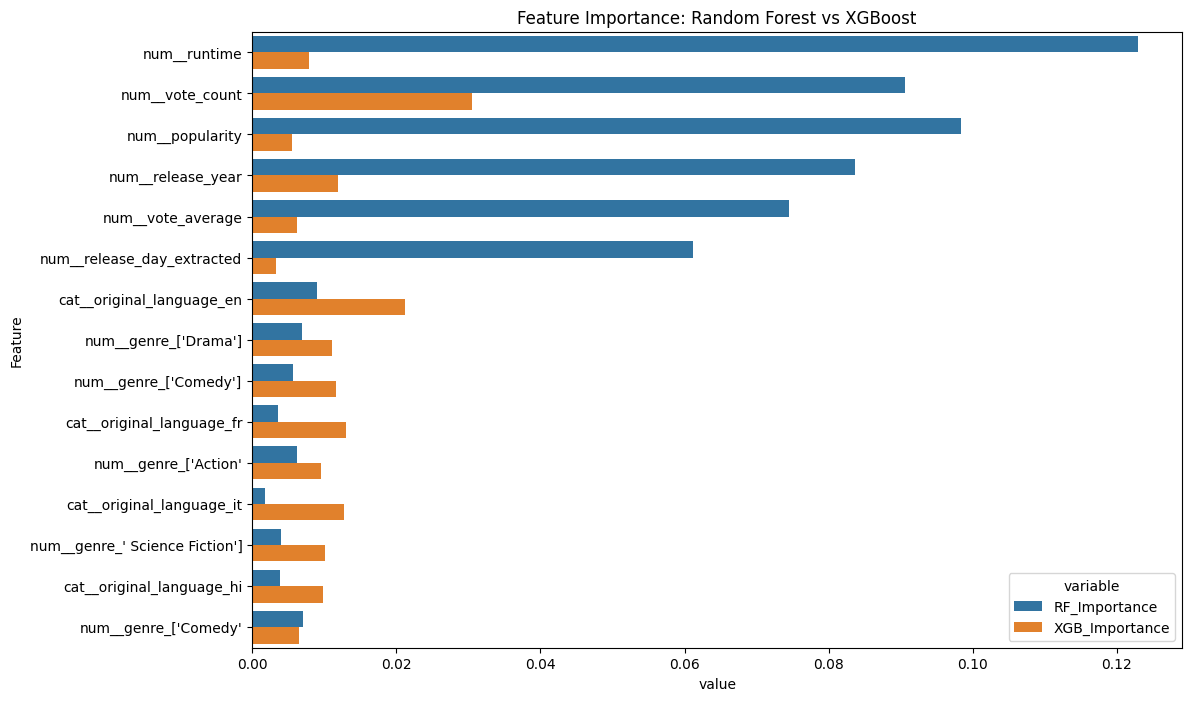

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare feature importance between models
rf_importances = rf_sel.feature_importances_
xgb_importances = xgb.feature_importances_

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'RF_Importance': rf_importances,
    'XGB_Importance': xgb_importances
})

importance_df['Avg_Importance'] = (importance_df['RF_Importance'] + importance_df['XGB_Importance']) / 2
importance_df = importance_df.sort_values('Avg_Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df[['Feature', 'Avg_Importance']].head(10))

# Plot feature importance comparison
top_features = importance_df.head(15)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_features.melt(id_vars='Feature', value_vars=['RF_Importance', 'XGB_Importance']),
    x='value', y='Feature', hue='variable'
)

plt.title('Feature Importance: Random Forest vs XGBoost')
plt.show()

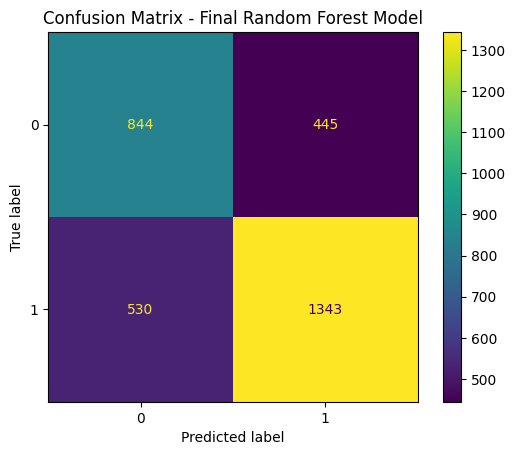

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_rf, X_test_sel, y_test)
plt.title("Confusion Matrix - Final Random Forest Model")
plt.show()

In [ ]:
import joblib

joblib.dump(best_rf, "final_movie_hit_flop_model.pkl")
print("Model saved successfully")

Model saved successfully


In [ ]:
### -----------------------------------
### Save Components for Future Use
### -----------------------------------
import joblib

# Create scaler and fit it on the selected training features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_sel)

# Save all required components
components_to_save = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'selected_features': top_features.index.tolist(),  # Your Random Forest selected features
    'feature_importance': top_features.to_dict()       # Save feature importance too
}

# Save each component separately
for name, component in components_to_save.items():
    joblib.dump(component, f'{name}.pkl')
    print(f"✅ Saved {name} to {name}.pkl")

# Also save a combined system file
joblib.dump(components_to_save, 'movie_classification_system.pkl')
print("✅ Saved complete system to movie_classification_system.pkl")

print("\n📊 Saved Components Summary:")
print(f"- Scaler: Fitted on {X_train_sel.shape[0]} training samples")
print(f"- Label Encoders: {len(label_encoders)} encoders")
print(f"- Selected Features: {len(top_features)} features")
print(f"- Feature Importance: Top feature = {top_features.index[0]} ({top_features.iloc[0]:.4f})")

✅ Saved scaler to scaler.pkl
✅ Saved label_encoders to label_encoders.pkl
✅ Saved selected_features to selected_features.pkl
✅ Saved feature_importance to feature_importance.pkl
✅ Saved complete system to movie_classification_system.pkl

📊 Saved Components Summary:
- Scaler: Fitted on 12646 training samples
- Label Encoders: 2 encoders
- Selected Features: 100 features
- Feature Importance: Top feature = popularity (0.0754)
